### Load Dataset

In [5]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset


dataset = LeRobotDataset(repo_id="whatevs", root="/storage/rproesma/clothes-hanger/datasets/b-n200-PREPR-INSTR0")

### Load resnet backbone from DP

In [6]:
from robot_imitation_glue.agents.lerobot_agent import make_lerobot_policy_for_inference


INCLUDE_INSTR = False
MODEL_NAME = f"b-n200-INSTR{1 if INCLUDE_INSTR else 0}-300k-1enc"
checkpoint_path = f"/home/rproesma/Documents/Projects/robot_imitation_glue/outputs/train/{MODEL_NAME}"

policy, preprocessor, postprocessor = make_lerobot_policy_for_inference(checkpoint_path)
# DiffusionPolicy has attribute diffusion [DiffusionModel], which has attribute rgb_encoder [DiffusionRgbEncoder], which has attribute backbone [ResNet, depending on config]
resnet_backbone = policy.diffusion.rgb_encoder.backbone


feature_map_shape = (512, 1, 1)
self.feature_dim = 512
Loading weights from local directory


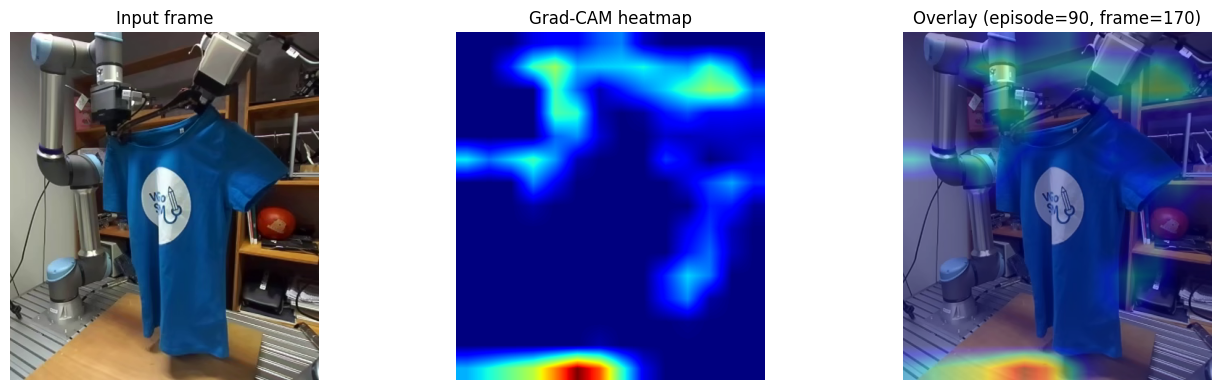

sample_idx=22643, camera_key=observation.images.scene_image, target_channel=390, device=cuda:0


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


# ---------- Choose frame ----------
EPISODE_INDEX = 90
FRAME_IN_EPISODE = 170
GLOBAL_SAMPLE_INDEX = None  # set this (int) to bypass episode/frame lookup
CAMERA_KEY = None  # e.g. "observation.images.front"; None -> auto-pick first image key
TARGET_CHANNEL = None  # None -> channel with max mean activation


# ---------- Resolve dataset sample index ----------
if GLOBAL_SAMPLE_INDEX is not None:
    sample_idx = int(GLOBAL_SAMPLE_INDEX)
else:
    sample_idx = None

    if hasattr(dataset, "episode_data_index"):
        from_idx = int(dataset.episode_data_index["from"][EPISODE_INDEX])
        to_idx = int(dataset.episode_data_index["to"][EPISODE_INDEX])
        episode_len = to_idx - from_idx
        if FRAME_IN_EPISODE < 0 or FRAME_IN_EPISODE >= episode_len:
            raise IndexError(f"FRAME_IN_EPISODE={FRAME_IN_EPISODE} out of range [0, {episode_len - 1}].")
        sample_idx = from_idx + FRAME_IN_EPISODE
    elif hasattr(dataset, "hf_dataset") and "episode_index" in dataset.hf_dataset.column_names:
        ep_indices = np.asarray(dataset.hf_dataset["episode_index"])
        in_ep = np.flatnonzero(ep_indices == EPISODE_INDEX)
        if len(in_ep) == 0:
            raise IndexError(f"No frames found for EPISODE_INDEX={EPISODE_INDEX}.")
        if FRAME_IN_EPISODE < 0 or FRAME_IN_EPISODE >= len(in_ep):
            raise IndexError(f"FRAME_IN_EPISODE={FRAME_IN_EPISODE} out of range [0, {len(in_ep) - 1}].")
        sample_idx = int(in_ep[FRAME_IN_EPISODE])

    if sample_idx is None:
        raise AttributeError(
            "Could not map (episode, frame) to a dataset index. "
            "Set GLOBAL_SAMPLE_INDEX directly or provide dataset episode metadata."
        )

sample = dataset[sample_idx]

image_keys = sorted([k for k in sample.keys() if k.startswith("observation.images")])
if len(image_keys) == 0:
    raise KeyError("No image observation keys found in sample.")

if CAMERA_KEY is None:
    CAMERA_KEY = image_keys[0]
if CAMERA_KEY not in image_keys:
    raise KeyError(f"{CAMERA_KEY=} not in available image keys: {image_keys}")

img = sample[CAMERA_KEY]
if not torch.is_tensor(img):
    img = torch.as_tensor(img)

# Ensure CHW float tensor in [0, 1].
img = img.float()
if img.max() > 1.0:
    img = img / 255.0

# ---------- Grad-CAM on last conv stage (layer4) ----------
backbone = resnet_backbone.eval()
if isinstance(backbone, torch.nn.Sequential):
    target_layer = backbone[-2]  # For ResNet children()[:-1], -2 is layer4 and -1 is avgpool.
else:
    raise TypeError("Expected `resnet_backbone` to be nn.Sequential.")

backbone_device = next(backbone.parameters()).device
x = img.unsqueeze(0).to(backbone_device)

activations = {}
gradients = {}


def fwd_hook(_module, _inp, out):
    activations["value"] = out


def bwd_hook(_module, grad_in, grad_out):
    gradients["value"] = grad_out[0]


handle_fwd = target_layer.register_forward_hook(fwd_hook)
handle_bwd = target_layer.register_full_backward_hook(bwd_hook)

with torch.enable_grad():
    x = x.requires_grad_(True)
    features = backbone(x)  # shape expected: [1, C, 1, 1]
    flattened = features.flatten(start_dim=1)

    if TARGET_CHANNEL is None:
        target_channel = int(flattened[0].argmax().item())
    else:
        target_channel = int(TARGET_CHANNEL)

    score = flattened[0, target_channel]
    backbone.zero_grad(set_to_none=True)
    score.backward()

handle_fwd.remove()
handle_bwd.remove()

acts = activations["value"]  # [1, C, H, W]
grads = gradients["value"]   # [1, C, H, W]

weights = grads.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
cam = (weights * acts).sum(dim=1, keepdim=True)  # [1, 1, H, W]
cam = F.relu(cam)

# Resize CAM to image resolution.
cam = F.interpolate(cam, size=img.shape[-2:], mode="bilinear", align_corners=False)
cam = cam[0, 0]
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)
cam_np = cam.detach().cpu().numpy()

img_np = img.permute(1, 2, 0).detach().cpu().numpy()

# ---------- Plot ----------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.title("Input frame")
plt.imshow(np.clip(img_np, 0.0, 1.0))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Grad-CAM heatmap")
plt.imshow(cam_np, cmap="jet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title(f"Overlay (episode={EPISODE_INDEX}, frame={FRAME_IN_EPISODE})")
plt.imshow(np.clip(img_np, 0.0, 1.0))
plt.imshow(cam_np, cmap="jet", alpha=0.4)
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"sample_idx={sample_idx}, camera_key={CAMERA_KEY}, target_channel={target_channel}, device={backbone_device}")

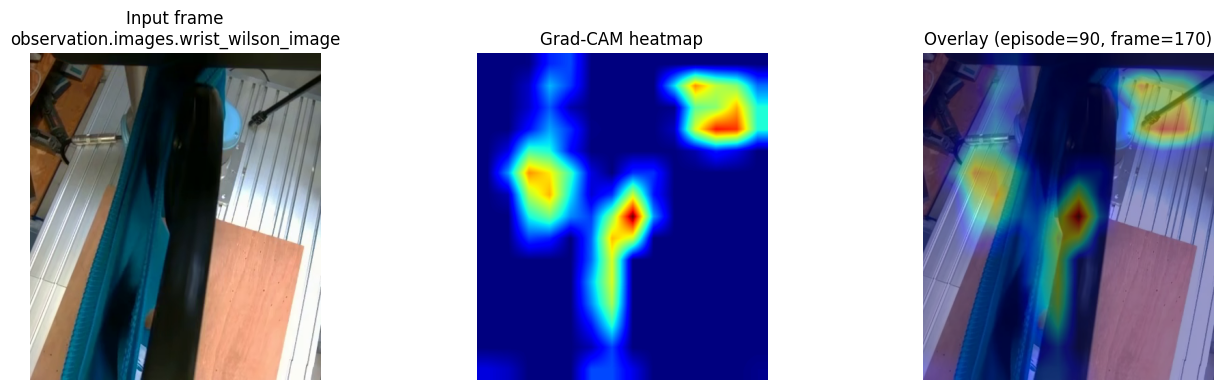

sample_idx=22643, camera_key=observation.images.wrist_wilson_image, target_channel=417, device=cuda:0


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


def visualize_cam_for_camera(camera_key: str, target_channel: int | None = None, alpha: float = 0.4):
    sample_local = dataset[sample_idx]
    if camera_key not in sample_local:
        available = sorted([k for k in sample_local.keys() if k.startswith("observation.images")])
        raise KeyError(f"{camera_key=} not found. Available image keys: {available}")

    img_local = sample_local[camera_key]
    if not torch.is_tensor(img_local):
        img_local = torch.as_tensor(img_local)
    img_local = img_local.float()
    if img_local.max() > 1.0:
        img_local = img_local / 255.0

    backbone_local = resnet_backbone.eval()
    target_layer_local = backbone_local[-2]
    device_local = next(backbone_local.parameters()).device
    x_local = img_local.unsqueeze(0).to(device_local).requires_grad_(True)

    activations_local = {}
    gradients_local = {}

    def fwd_hook(_module, _inp, out):
        activations_local["value"] = out

    def bwd_hook(_module, _gin, gout):
        gradients_local["value"] = gout[0]

    h1 = target_layer_local.register_forward_hook(fwd_hook)
    h2 = target_layer_local.register_full_backward_hook(bwd_hook)

    with torch.enable_grad():
        feats = backbone_local(x_local)
        flat = feats.flatten(start_dim=1)
        ch = int(flat[0].argmax().item()) if target_channel is None else int(target_channel)
        score = flat[0, ch]
        backbone_local.zero_grad(set_to_none=True)
        score.backward()

    h1.remove()
    h2.remove()

    acts_local = activations_local["value"]
    grads_local = gradients_local["value"]
    weights_local = grads_local.mean(dim=(2, 3), keepdim=True)
    cam_local = F.relu((weights_local * acts_local).sum(dim=1, keepdim=True))
    cam_local = F.interpolate(cam_local, size=img_local.shape[-2:], mode="bilinear", align_corners=False)
    cam_local = cam_local[0, 0]
    cam_local = cam_local - cam_local.min()
    cam_local = cam_local / (cam_local.max() + 1e-8)

    cam_np_local = cam_local.detach().cpu().numpy()
    img_np_local = img_local.permute(1, 2, 0).detach().cpu().numpy()

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.title(f"Input frame\n{camera_key}")
    plt.imshow(np.clip(img_np_local, 0.0, 1.0))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Grad-CAM heatmap")
    plt.imshow(cam_np_local, cmap="jet")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Overlay (episode={EPISODE_INDEX}, frame={FRAME_IN_EPISODE})")
    plt.imshow(np.clip(img_np_local, 0.0, 1.0))
    plt.imshow(cam_np_local, cmap="jet", alpha=alpha)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"sample_idx={sample_idx}, camera_key={camera_key}, target_channel={ch}, device={device_local}")


visualize_cam_for_camera("observation.images.wrist_wilson_image")